# Employee Attrition Prediction using Decision Tree and Random Forest

**Assignment 5 — AI/ML**

**Objective:** Predict whether an employee is likely to leave the company
(attrition), using demographic, professional, and work-related attributes, and
compare a Decision Tree classifier against a Random Forest classifier.

**Dataset:** [IBM HR Analytics Employee Attrition & Performance Dataset (Kaggle)](https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset)


## Task 1: Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)


In [2]:
# Load the dataset
df = pd.read_csv("hr_attrition.csv")
df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
print("Shape:", df.shape)
df.info()


Shape: (1470, 35)
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 no

In [4]:
df.describe()


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,2.728571,6502.931293,14313.103401,2.693197,15.209524,3.153741,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,1.102846,4707.956783,7117.786044,2.498009,3.659938,0.360824,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,1.000000,1009.000000,2094.000000,0.000000,11.000000,3.000000,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,2.000000,2911.000000,8047.000000,1.000000,12.000000,3.000000,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,3.000000,4919.000000,14235.500000,2.000000,14.000000,3.000000,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,4.000000,8379.000000,20461.500000,4.000000,18.000000,3.000000,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,4.000000,19999.000000,26999.000000,9.000000,25.000000,4.000000,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include='object').columns.tolist()
categorical_features.remove('Attrition')  # Attrition is the target, not a feature

print("Numerical features:", numerical_features)
print()
print("Categorical features:", categorical_features)
print()
print("Target variable: Attrition")


Numerical features: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical features: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']

Target variable: Attrition


/tmp/ipykernel_537/3150567206.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = df.select_dtypes(include='object').columns.tolist()


## Task 2: Data Preprocessing

In [6]:
# Check for missing values
df.isnull().sum().sum()


np.int64(0)

In [7]:
# Remove unnecessary columns:
# - EmployeeNumber: unique ID, not predictive
# - EmployeeCount, StandardHours, Over18: constant for every row (no information)
for col in ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber']:
    print(col, "-> unique values:", df[col].nunique())

df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])
print("\nShape after dropping unnecessary columns:", df.shape)


EmployeeCount -> unique values: 1
StandardHours -> unique values: 1
Over18 -> unique values: 1
EmployeeNumber -> unique values: 1470

Shape after dropping unnecessary columns: (1470, 31)


In [8]:
# Encode the target variable: No -> 0, Yes -> 1
le_target = LabelEncoder()
df['Attrition'] = le_target.fit_transform(df['Attrition'])
print("Classes:", list(le_target.classes_), "-> encoded as", list(le_target.transform(le_target.classes_)))


Classes: ['No', 'Yes'] -> encoded as [np.int64(0), np.int64(1)]


In [9]:
# One-hot encode the remaining categorical features
remaining_cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Encoding:", remaining_cat_cols)

df_encoded = pd.get_dummies(df, columns=remaining_cat_cols, drop_first=True)
print("Encoded shape:", df_encoded.shape)
df_encoded.head()


Encoding: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Encoded shape: (1470, 45)


/tmp/ipykernel_537/100998320.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  remaining_cat_cols = df.select_dtypes(include='object').columns.tolist()


,Age,Attrition,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,2,94,3,2,4,5993,19479,8,11,3,1,0,8,0,1,6,4,0,5,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,True
1,49,0,279,8,1,3,61,2,2,2,5130,24907,1,23,4,4,1,10,3,3,10,7,1,7,True,False,True,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,False
2,37,1,1373,2,2,4,92,2,1,3,2090,2396,6,15,3,2,0,7,3,3,0,0,0,0,False,True,True,False,False,False,False,True,False,True,False,True,False,False,False,False,False,False,False,True,True
3,33,0,1392,3,4,4,56,3,1,3,2909,23159,1,11,3,3,0,8,3,3,8,7,3,0,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True
4,27,0,591,2,1,1,40,3,1,2,3468,16632,9,12,3,4,1,6,3,3,2,2,2,2,False,True,True,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False


In [10]:
X = df_encoded.drop('Attrition', axis=1)
y = df_encoded['Attrition']

# 80/20 split, stratified since attrition is imbalanced (~16% Yes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nAttrition rate - train:", y_train.mean().round(3), "| test:", y_test.mean().round(3))


Training set shape: (1176, 44)
Testing set shape: (294, 44)

Attrition rate - train: 0.162 | test: 0.16


## Task 3: Model Development

In [11]:
# Model 1: Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


In [12]:
# Model 2: Random Forest Classifier (100 estimators)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


## Task 4: Model Evaluation and Comparison

In [13]:
def evaluate(name, y_true, y_pred):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred),
    }

results = pd.DataFrame([
    evaluate('Decision Tree', y_test, y_pred_dt),
    evaluate('Random Forest', y_test, y_pred_rf),
])
results


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.765306,0.310345,0.382979,0.342857
1,Random Forest,0.833333,0.416667,0.106383,0.169492


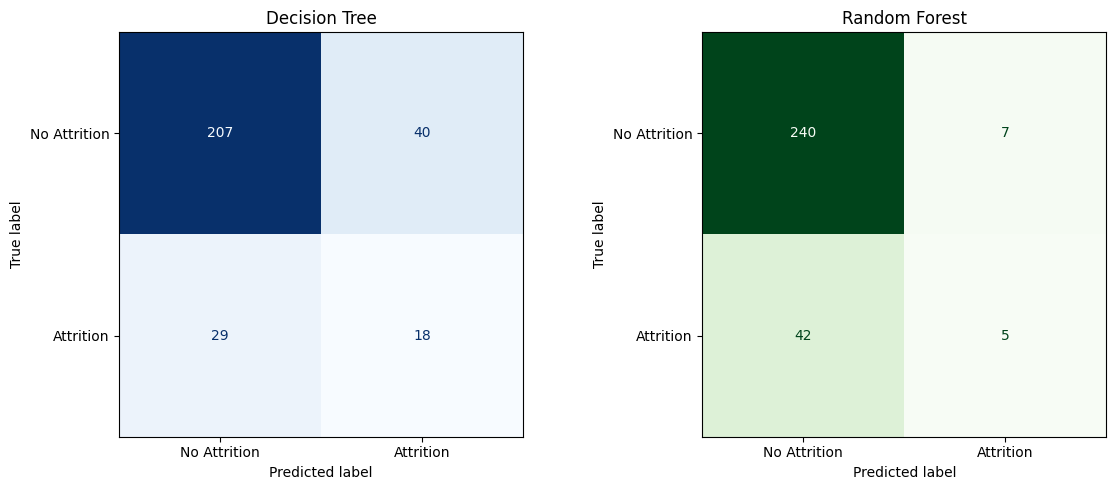

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=['No Attrition', 'Attrition']).plot(
    ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('Decision Tree')

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['No Attrition', 'Attrition']).plot(
    ax=axes[1], cmap='Greens', values_format='d', colorbar=False)
axes[1].set_title('Random Forest')

plt.tight_layout()
plt.show()


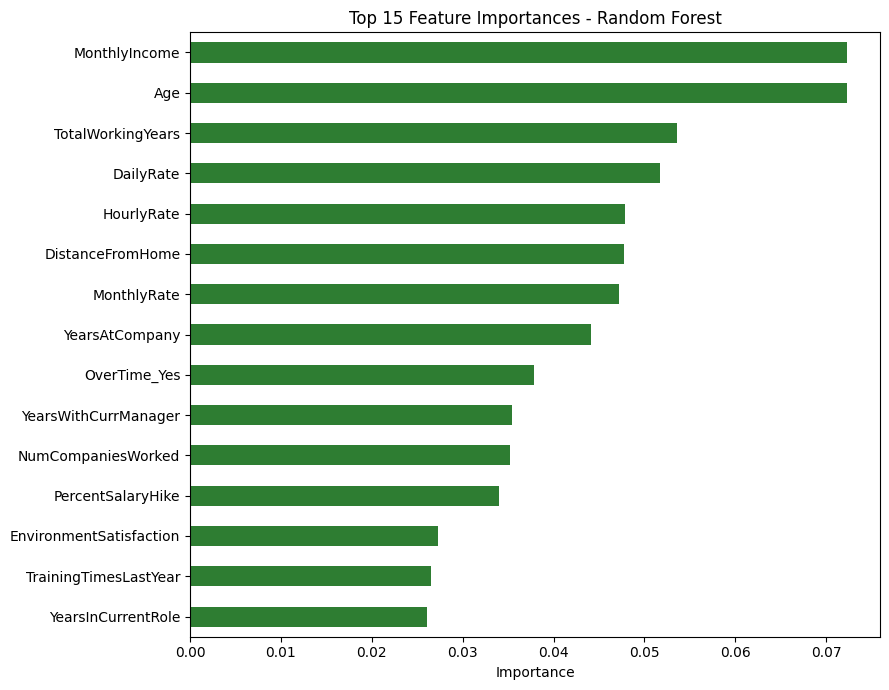

In [15]:
# Feature importance - Random Forest
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 7))
top_importances.sort_values().plot(kind='barh', color='#2e7d32')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()


### Observations

1. **Random Forest wins on accuracy (≈ 0.833 vs. ≈ 0.765), but the picture flips on
   recall for the attrition class** (Decision Tree ≈ 0.38 vs. Random Forest ≈ 0.11) —
   with attrition making up only ~16% of employees, a model can score well on accuracy
   just by predicting "No" most of the time, which is closer to what Random Forest is
   doing here.
2. **Random Forest is much more conservative about predicting attrition** — its
   confusion matrix shows very few false positives but a large number of false
   negatives (actual leavers predicted as staying), while the single Decision Tree
   predicts "Yes" more often, catching more true leavers at the cost of more false
   alarms.
3. **`MonthlyIncome`, `Age`, `TotalWorkingYears`, and `OverTime` are the strongest
   predictors** in the Random Forest's feature importances — consistent with the
   real-world intuition that lower pay, younger/less-experienced employees, and
   working overtime are associated with higher attrition risk.
4. **Accuracy alone is a misleading way to pick a winner here.** If the business
   priority is catching as many at-risk employees as possible (high recall), the plain
   Decision Tree is arguably more useful despite its lower accuracy and F1, since
   Random Forest's default threshold is missing about 9 in 10 actual leavers in this
   run.


## Bonus: Hyperparameter Tuning Experiment (not for marks)

In [16]:
# Tuning max_depth for the Random Forest
for depth in [5, 10, 15, None]:
    rf_tuned = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    rf_tuned.fit(X_train, y_train)
    y_pred_tuned = rf_tuned.predict(X_test)
    print(f"max_depth={depth}: accuracy={accuracy_score(y_test, y_pred_tuned):.4f}, "
          f"f1={f1_score(y_test, y_pred_tuned):.4f}")


max_depth=5: accuracy=0.8299, f1=0.1071


max_depth=10: accuracy=0.8367, f1=0.1724


max_depth=15: accuracy=0.8333, f1=0.1695


max_depth=None: accuracy=0.8333, f1=0.1695


Limiting `max_depth` to **10** gave a small improvement over the unrestricted
default (accuracy ≈ 0.837 vs. ≈ 0.833, F1 ≈ 0.172 vs. ≈ 0.169). Restricting tree depth
forces each of the 100 trees to be a bit less specialized to the exact training rows, which
can slightly reduce overfitting; however, the improvement here is marginal because the
class imbalance — not tree depth — is the main factor limiting recall on the attrition
class.


## Task 5: Conclusion

Both a Decision Tree and a Random Forest (100 estimators) were trained to predict
employee attrition from 30 demographic, professional, and work-related features after
dropping constant/identifier columns and one-hot encoding the categorical variables.
Random Forest achieved the higher accuracy (≈0.83 vs ≈0.77) and precision, but the
Decision Tree actually achieved noticeably higher recall on the attrition class (≈0.38 vs
≈0.11), meaning it caught more of the employees who genuinely left, at the cost of more
false alarms — a reminder that "better model" depends on which error type the business
cares about more. Random Forest generally outperforms a single Decision Tree because it
trains many trees on bootstrapped samples with random feature subsets and averages their
votes, which reduces the variance and overfitting that a single deep tree is prone to,
usually producing more stable predictions on unseen data. A key limitation of Decision
Trees is that a single tree can overfit the training data very easily, memorizing noise
and quirks specific to the training rows, which hurts generalization. A key limitation of
Random Forest is that it trades away most of a single tree's interpretability — you can no
longer trace one clear decision path — and, as seen here, an ensemble tuned for overall
accuracy can end up biased toward the majority class on an imbalanced target unless that
imbalance is explicitly addressed (e.g., class weighting, resampling, or threshold
tuning).
